**Essential Data Cleaning Steps** 
* Lowercasing – convert all text to lowercase.
* Remove HTML Tags – using regex or BeautifulSoup.
* Remove URLs – re.sub(r"http\S+|www\S+|https\S+", '', text).
* Remove Punctuation – string.punctuation via regex.
* Remove Numbers – often done in classification tasks unless numbers are meaningful.
* Tokenization – splitting sentences into words.
* Stopword Removal – using nltk.corpus.stopwords.
* Lemmatization – which you're doing now (with WordNet).
* Whitespace Normalization – removing extra spaces or tabs.
* Handle Emojis / Special Symbols – remove or convert to text using emoji lib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Read the data....

In [3]:
test = pd.read_csv('test.csv')
train = pd.read_csv('train.csv')

test.shape,train.shape

((153164, 2), (159571, 8))

In [4]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
test.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [6]:
labels = pd.read_csv('test_labels.csv')
labels.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,-1,-1,-1,-1,-1,-1
1,0000247867823ef7,-1,-1,-1,-1,-1,-1
2,00013b17ad220c46,-1,-1,-1,-1,-1,-1
3,00017563c3f7919a,-1,-1,-1,-1,-1,-1
4,00017695ad8997eb,-1,-1,-1,-1,-1,-1


In [7]:
train.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [8]:
# Data Understanding.....

In [9]:
train.isna().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [10]:
test.isna().sum()

id              0
comment_text    0
dtype: int64

In [11]:
labels.isna().sum()

id               0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [12]:
for i in train.columns:
    if i != "comment_text" and i!= "id":
        print(train[i].value_counts())
        print("=======================")

0    144277
1     15294
Name: toxic, dtype: int64
0    157976
1      1595
Name: severe_toxic, dtype: int64
0    151122
1      8449
Name: obscene, dtype: int64
0    159093
1       478
Name: threat, dtype: int64
0    151694
1      7877
Name: insult, dtype: int64
0    158166
1      1405
Name: identity_hate, dtype: int64


In [13]:
train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [14]:
# Create a new column 'any_label' where it's 1 if any of the labels are 1
train['any_label'] = ((train['toxic'] == 1) |
                      (train['severe_toxic'] == 1) |
                      (train['obscene'] == 1) |
                      (train['threat'] == 1) |
                      (train['insult'] == 1) |
                      (train['identity_hate'] == 1)).astype(int)


In [15]:
train.loc[train['any_label'].isna()==True] = 0
train.any_label.value_counts()

0    143346
1     16225
Name: any_label, dtype: int64

In [16]:
train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,any_label
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,0


In [17]:
print(round((train.any_label.value_counts()[1]/train.shape[0])*100,2),"% of the comments are toxic.")

10.17 % of the comments are toxic.


In [18]:
count_1 = int()
count_0 = int()
for i in train.columns:
    if i != "comment_text" and i!= "id":
        count_1 += train[i].value_counts()[1]
        count_0 += train[i].value_counts()[0]
print('count of 0:',count_0)
print('count of 1:',count_1)

count of 0: 1065674
count of 1: 51323


In [19]:
train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,any_label
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0,0


In [20]:
label_columns = ['obscene', 'threat', 'insult', 'identity_hate','severe_toxic','toxic']

# Filter toxic comments
toxic_df = train[train['severe_toxic'] == 1]
total_toxic = len(toxic_df)

# Generate the summary
for label in label_columns:
    count = toxic_df[label].sum()
    percent = (count / total_toxic) * 100
    print(f"{int(count)} or {percent:.2f}% were also {label}.")

1517 or 95.11% were also obscene.
112 or 7.02% were also threat.
1371 or 85.96% were also insult.
313 or 19.62% were also identity_hate.
1595 or 100.00% were also severe_toxic.
1595 or 100.00% were also toxic.


In [21]:
label_columns = ['obscene', 'threat', 'insult', 'identity_hate','severe_toxic','toxic']

# Filter threat comments
toxic_df = train[train['threat'] == 1]
total_toxic = len(toxic_df)

# Generate the summary
for label in label_columns:
    count = toxic_df[label].sum()
    percent = (count / total_toxic) * 100
    print(f"{int(count)} or {percent:.2f}% were also {label}.")

301 or 62.97% were also obscene.
478 or 100.00% were also threat.
307 or 64.23% were also insult.
98 or 20.50% were also identity_hate.
112 or 23.43% were also severe_toxic.
449 or 93.93% were also toxic.


In [22]:
label_columns = ['obscene', 'threat', 'insult', 'identity_hate','severe_toxic','toxic']

# Filter insult comments
toxic_df = train[train['insult'] == 1]
total_toxic = len(toxic_df)

# Generate the summary
for label in label_columns:
    count = toxic_df[label].sum()
    percent = (count / total_toxic) * 100
    print(f"{int(count)} or {percent:.2f}% were also {label}.")

6155 or 78.14% were also obscene.
307 or 3.90% were also threat.
7877 or 100.00% were also insult.
1160 or 14.73% were also identity_hate.
1371 or 17.41% were also severe_toxic.
7344 or 93.23% were also toxic.


In [23]:
label_columns = ['obscene', 'threat', 'insult', 'identity_hate','severe_toxic','toxic']

# Filter obscene comments
toxic_df = train[train['obscene'] == 1]
total_toxic = len(toxic_df)

# Generate the summary
for label in label_columns:
    count = toxic_df[label].sum()
    percent = (count / total_toxic) * 100
    print(f"{int(count)} or {percent:.2f}% were also {label}.")

8449 or 100.00% were also obscene.
301 or 3.56% were also threat.
6155 or 72.85% were also insult.
1032 or 12.21% were also identity_hate.
1517 or 17.95% were also severe_toxic.
7926 or 93.81% were also toxic.


In [24]:
label_columns = ['obscene', 'threat','toxic', 'insult', 'identity_hate','severe_toxic']

# Filter identity hate comments
toxic_df = train[train['identity_hate'] == 1]
total_toxic = len(toxic_df)

# Generate the summary
for label in label_columns:
    count = toxic_df[label].sum()
    percent = (count / total_toxic) * 100
    print(f"{int(count)} or {percent:.2f}% were also {label}.")

1032 or 73.45% were also obscene.
98 or 6.98% were also threat.
1302 or 92.67% were also toxic.
1160 or 82.56% were also insult.
1405 or 100.00% were also identity_hate.
313 or 22.28% were also severe_toxic.


### EDA...

In [25]:
combined = pd.concat([train,test])
combined.shape

(312735, 9)

In [26]:
combined.drop(columns="id",inplace=True)
combined.shape

(312735, 8)

In [27]:
combined.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,any_label
0,Explanation\nWhy the edits made under my usern...,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,D'aww! He matches this background colour I'm s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"Hey man, I'm really not trying to edit war. It...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"""\nMore\nI can't make any real suggestions on ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"You, sir, are my hero. Any chance you remember...",0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
combined.iloc[3,0]

'"\nMore\nI can\'t make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ""types of accidents""  -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It\'s listed in the relevant form eg Wikipedia:Good_article_nominations#Transport  "'

In [29]:
combined['comment_text_1'] = combined['comment_text'].str.lower()

In [30]:
combined['comment_text_1']

0         explanation\nwhy the edits made under my usern...
1         d'aww! he matches this background colour i'm s...
2         hey man, i'm really not trying to edit war. it...
3         "\nmore\ni can't make any real suggestions on ...
4         you, sir, are my hero. any chance you remember...
                                ...                        
153159    . \n i totally agree, this stuff is nothing bu...
153160    == throw from out field to home plate. == \n\n...
153161    " \n\n == okinotorishima categories == \n\n i ...
153162    " \n\n == ""one of the founding nations of the...
153163    " \n :::stop already. your bullshit is not wel...
Name: comment_text_1, Length: 312735, dtype: object

In [31]:
# Using regular epression clean the text and remove the html tags or any url or any irrelevant email address...

In [32]:
import re

In [33]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'\S+@\S+', '', text)  # Remove email addresses
    return text

In [34]:
combined['comment_text_1'] = combined['comment_text'].apply(clean_text)

In [35]:
# lets remove special characters and numbers or extra spaces...

In [36]:
combined['comment_text_1'] = combined['comment_text_1'].apply((lambda x: re.sub(r'[^a-zA-Z\s]', '', x)))

In [37]:
combined['comment_text_1'] = combined['comment_text_1'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

In [38]:
import contractions

combined['comment_text_1'] = combined['comment_text_1'].apply(lambda x: contractions.fix(x))

In [39]:
combined['comment_text'].iloc[3]

'"\nMore\nI can\'t make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ""types of accidents""  -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It\'s listed in the relevant form eg Wikipedia:Good_article_nominations#Transport  "'

In [40]:

combined['comment_text_1'].iloc[3]

'More I cannot make any real suggestions on improvement I wondered if the section statistics should be later on or a subsection of types of accidents I think the references may need tidying so that they are all in the exact same format ie date format etc I can do that later on if noone else does first if you have any preferences for formatting style on references or want to do it yourself please let me know There appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up Its listed in the relevant form eg WikipediaGoodarticlenominationsTransport'

## NLP...

In [41]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize



In [42]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    return ' '.join([word for word in tokens if word not in stop_words])

combined['comment_text_1'] = combined['comment_text_1'].apply(remove_stopwords)

In [43]:
combined['comment_text_1'].iloc[3]

'More I make real suggestions improvement I wondered section statistics later subsection types accidents I think references may need tidying exact format ie date format etc I later noone else first preferences formatting style references want please let know There appears backlog articles review I guess may delay reviewer turns Its listed relevant form eg WikipediaGoodarticlenominationsTransport'

In [44]:
combined['comment_text'].iloc[3]

'"\nMore\nI can\'t make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of ""types of accidents""  -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It\'s listed in the relevant form eg Wikipedia:Good_article_nominations#Transport  "'

In [45]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
from nltk.stem import WordNetLemmatizer
#nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in word_tokenize(text)])

combined['comment_text_1'] = combined['comment_text_1'].apply(lemmatize_text)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [47]:
combined['comment_text_1'].iloc[0]

'Explanation Why edits made username Hardcore Metallica Fan reverted They vandalism closure GAs I voted New York Dolls FAC And please remove template talk page since I Am retired'

In [48]:
combined['comment_text'].iloc[0]

"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27"

In [49]:
combined['comment_text_1'].iloc[0]

'Explanation Why edits made username Hardcore Metallica Fan reverted They vandalism closure GAs I voted New York Dolls FAC And please remove template talk page since I Am retired'

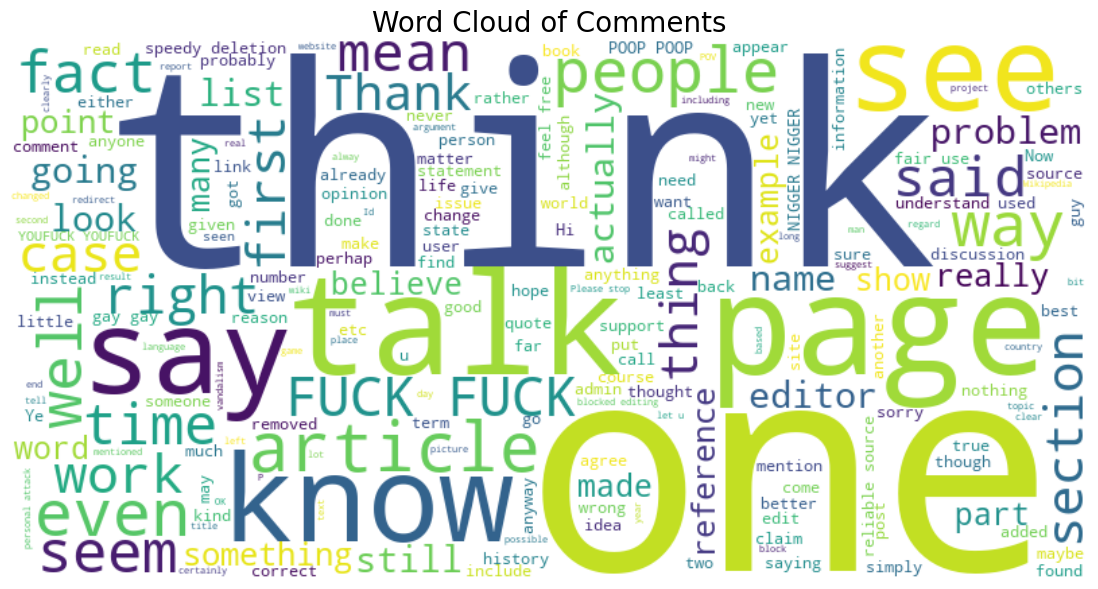

In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


text_data = " ".join(comment for comment in combined['comment_text_1'])

# Create a word cloud object
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      max_words=200, colormap='viridis').generate(text_data)

# Plotting the Word Cloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Comments', fontsize=20)
plt.show()


In [50]:
combined.isna().sum()

comment_text           0
toxic             153164
severe_toxic      153164
obscene           153164
threat            153164
insult            153164
identity_hate     153164
any_label         153164
comment_text_1         0
dtype: int64

In [51]:
targets = train.columns[2:]
train_targets = train[targets].copy()
train_targets_1 = combined[targets].copy()


for t in targets:
    print("Label: %s ============================================================" % t)
    b = np.where(train_targets[t]==1)[0]
    selection = np.random.choice(b, size=10)
    for s in selection:
        print(train.comment_text.loc[s])
        print("++++++++++++")
    print()
    
b = np.where(train_targets_1.any_label==0)[0]
selection = np.random.choice(b, 10)
print("Clean comments =========================================")
for s in selection:
    print(combined.comment_text_1.loc[s])
    print("++++++++++++")


Label: toxic ============================================================
Don't you want my penis?
++++++++++++
What's up my nigger? 

Promoting yourself on Wikipedia is a bad idea. You should probably go somewhere else. Maybe you could post some hand-drawn posters in your ghetto?
++++++++++++
may God spare your soul you are going to hell you worthless piece of shit. Maybe you will have fun when satan is ass fucking u instead of your queer little buddies fuck off and btw kick me off wikipedia you queer ass bitch fuck off and burn in hell bitch!
++++++++++++
"
No. You are quite blatantly the troll here, and the others who have pointed this out, including user:Egg Centric, are right. As I mentioned before, there is no place on wikipedia for ""TheIrishWarden"". You may have fooled some of us, but you won't get away with this for long! 94.2.68.11  "
++++++++++++
He deserved it.  Go suck one.
++++++++++++
Ah, I see what you mean - that's fine then.

You speak like a total fucking cunt, but 

### Feature Engineering...

In [52]:
import re
import numpy as np
import pandas as pd
from scipy import sparse

def feature_engineering(combined):
    # Comment length
    combined['length'] = combined['comment_text'].apply(len)

    # Capitalization percentage
    def pct_caps(s):
        return sum(c.isupper() for c in s) / (sum(c.isalpha() for c in s) + 1)
    combined['caps'] = combined['comment_text'].apply(pct_caps)

    # Mean word length
    def word_length(s):
        words = s.split()
        word_lengths = [len(w) for w in words if w.isalpha()]
        return np.mean(word_lengths) if word_lengths else 0
    combined['word_length'] = combined['comment_text'].apply(word_length)

    # Number of exclamation and question marks
    combined['exclamation'] = combined['comment_text'].apply(lambda s: s.count('!'))
    combined['question'] = combined['comment_text'].apply(lambda s: s.count('?'))

    # Normalize features to 0–1
    for col in ['length', 'caps', 'word_length', 'exclamation', 'question']:
        minimum = combined[col].min()
        diff = combined[col].max() - minimum
        combined[col] = combined[col].apply(lambda x: (x - minimum) / (diff if diff > 0 else 1))

    # Remove IP addresses
    ip_regex = re.compile(
        r'(([2][5][0-5]\.)|([2][0-4][0-9]\.)|([0-1]?[0-9]?[0-9]\.)){3}'
        r'(([2][5][0-5])|([2][0-4][0-9])|([0-1]?[0-9]?[0-9]))'
    )
    
    def strip_ip(s):
        try:
            found = ip_regex.search(s)
            return s.replace(found.group(), '') if found else s
        except:
            return s
    combined['comment_text'] = combined['comment_text'].apply(strip_ip)

    return combined


In [53]:
combined = feature_engineering(combined)

In [54]:
combined.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,any_label,comment_text_1,length,caps,word_length,exclamation,question
0,Explanation\nWhy the edits made under my usern...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Explanation Why edits made username Hardcore M...,0.052611,0.083350,0.001872,0.000000,0.000868
1,D'aww! He matches this background colour I'm s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Daww He match background colour I Am seemingly...,0.022204,0.108130,0.002522,0.000201,0.000000
2,"Hey man, I'm really not trying to edit war. It...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hey man I Am really trying edit war Its guy co...,0.046409,0.021395,0.001872,0.000000,0.000000
3,"""\nMore\nI can't make any real suggestions on ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,More I make real suggestion improvement I wond...,0.124225,0.022592,0.001689,0.000000,0.000000
4,"You, sir, are my hero. Any chance you remember...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,You sir hero Any chance remember page,0.013203,0.039224,0.001665,0.000000,0.000868


In [55]:
combined.shape

(312735, 14)

In [56]:
# Applying Models and NLP 

In [57]:
combined[combined.any_label.notna()]

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,any_label,comment_text_1,length,caps,word_length,exclamation,question
0,Explanation\nWhy the edits made under my usern...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Explanation Why edits made username Hardcore M...,0.052611,0.083350,0.001872,0.000000,0.000868
1,D'aww! He matches this background colour I'm s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Daww He match background colour I Am seemingly...,0.022204,0.108130,0.002522,0.000201,0.000000
2,"Hey man, I'm really not trying to edit war. It...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hey man I Am really trying edit war Its guy co...,0.046409,0.021395,0.001872,0.000000,0.000000
3,"""\nMore\nI can't make any real suggestions on ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,More I make real suggestion improvement I wond...,0.124225,0.022592,0.001689,0.000000,0.000000
4,"You, sir, are my hero. Any chance you remember...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,You sir hero Any chance remember page,0.013203,0.039224,0.001665,0.000000,0.000868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,""":::::And for the second time of asking, when ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,And second time asking view completely contrad...,0.058812,0.008774,0.001984,0.000000,0.001736
159567,You should be ashamed of yourself \n\nThat is ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,You ashamed That horrible thing put talk page,0.019604,0.029857,0.001564,0.000000,0.000000
159568,"Spitzer \n\nUmm, theres no actual article for ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,Spitzer Umm actual article prostitution ring C...,0.016003,0.062513,0.002472,0.000000,0.000000
159569,And it looks like it was actually you who put ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,And look like actually put speedy first versio...,0.023005,0.021744,0.001497,0.000000,0.000000


In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_text = tfidf.fit_transform(combined['comment_text_1'])

In [60]:
from scipy.sparse import hstack, csr_matrix

# Convert numeric features to sparse matrix
numeric_sparse = csr_matrix(numeric_features)

X = hstack([X_text[:len(train)], numeric_sparse[:len(train)]])
X_test = hstack([X_text[len(train):], numeric_sparse[len(train):]])


numeric_features = combined[['length', 'caps', 'word_length', 'exclamation', 'question']].values

numeric_sparse = csr_matrix(numeric_features)

X = hstack([X_text[:len(train)], numeric_sparse[:len(train)]])
X_test = hstack([X_text[len(train):], numeric_sparse[len(train):]])

# Target labels
y = train[label_columns].values

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [62]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

In [65]:
rf_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1))
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("=== Random Forest Report ===")
classification_report(y_test, y_pred_rf, target_names=label_columns)

=== Random Forest Report ===
               precision    recall  f1-score   support

      obscene       0.87      0.64      0.74      1715
       threat       0.25      0.03      0.05        74
        toxic       0.86      0.58      0.69      3056
       insult       0.76      0.47      0.58      1614
identity_hate       0.81      0.10      0.18       294
 severe_toxic       0.46      0.06      0.10       321

    micro avg       0.83      0.52      0.64      7074
    macro avg       0.67      0.31      0.39      7074
 weighted avg       0.81      0.52      0.62      7074
  samples avg       0.05      0.05      0.05      7074



In [66]:
gbm_model = OneVsRestClassifier(GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42))
gbm_model.fit(X_train, y_train)

y_pred_gbm = gbm_model.predict(X_test)
print("=== Gradient Boosting Report ===")
classification_report(y_test, y_pred_gbm, target_names=label_columns)

=== Gradient Boosting Report ===


'               precision    recall  f1-score   support\n\n      obscene       0.94      0.51      0.66      1715\n       threat       0.34      0.22      0.26        74\n        toxic       0.94      0.37      0.53      3056\n       insult       0.84      0.34      0.48      1614\nidentity_hate       0.61      0.21      0.32       294\n severe_toxic       0.56      0.22      0.32       321\n\n    micro avg       0.88      0.38      0.53      7074\n    macro avg       0.70      0.31      0.43      7074\n weighted avg       0.88      0.38      0.53      7074\n  samples avg       0.04      0.03      0.03      7074\n'

In [69]:
print(classification_report(y_test, y_pred_gbm, target_names=label_columns))

               precision    recall  f1-score   support

      obscene       0.94      0.51      0.66      1715
       threat       0.34      0.22      0.26        74
        toxic       0.94      0.37      0.53      3056
       insult       0.84      0.34      0.48      1614
identity_hate       0.61      0.21      0.32       294
 severe_toxic       0.56      0.22      0.32       321

    micro avg       0.88      0.38      0.53      7074
    macro avg       0.70      0.31      0.43      7074
 weighted avg       0.88      0.38      0.53      7074
  samples avg       0.04      0.03      0.03      7074



In [67]:
xgb_model = OneVsRestClassifier(XGBClassifier(n_estimators=50, learning_rate=0.1,
                                              use_label_encoder=False, eval_metric='logloss', random_state=42, verbosity=0))
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
print("=== XGBoost Report ===")
classification_report(y_test, y_pred_xgb, target_names=label_columns)

=== XGBoost Report ===


'               precision    recall  f1-score   support\n\n      obscene       0.92      0.58      0.71      1715\n       threat       0.52      0.15      0.23        74\n        toxic       0.93      0.45      0.61      3056\n       insult       0.82      0.42      0.56      1614\nidentity_hate       0.69      0.13      0.22       294\n severe_toxic       0.67      0.13      0.22       321\n\n    micro avg       0.89      0.44      0.59      7074\n    macro avg       0.76      0.31      0.42      7074\n weighted avg       0.88      0.44      0.58      7074\n  samples avg       0.04      0.04      0.04      7074\n'

In [68]:
print(classification_report(y_test, y_pred_xgb, target_names=label_columns))

               precision    recall  f1-score   support

      obscene       0.92      0.58      0.71      1715
       threat       0.52      0.15      0.23        74
        toxic       0.93      0.45      0.61      3056
       insult       0.82      0.42      0.56      1614
identity_hate       0.69      0.13      0.22       294
 severe_toxic       0.67      0.13      0.22       321

    micro avg       0.89      0.44      0.59      7074
    macro avg       0.76      0.31      0.42      7074
 weighted avg       0.88      0.44      0.58      7074
  samples avg       0.04      0.04      0.04      7074



* As the XGB gives highest Accuracy so we conclude that it is our final model.